# Day 3: Data Cleaning & Synthetic Data Generation

**Project:** E-commerce Conversion Intelligence Platform  
**Author:** Aishwarya Kadam  
**Date:** April 10, 2026  

## Objectives
1. Apply modular cleaning pipeline to raw 2024 data
2. Generate synthetic 2025 data to enrich the dataset
3. Combine real + synthetic into a master dataset
4. Save cleaned data to `data/processed/`
5. Validate data quality of combined dataset

In [1]:
# Add src to path so we can import our modules
import sys
sys.path.append('..')

# Import our custom modules
from src.transformation.cleaners import (
    load_raw_data,
    clean_pipeline,
    data_quality_report
)
from src.ingestion.generate_synthetic import (
    generate_synthetic_data,
    save_synthetic_data
)

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All modules imported successfully!")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
✅ All modules imported successfully!


## 1. Load and Clean Raw 2024 Data

In [2]:
# Load raw clickstream data
raw_df = load_raw_data('../data/raw/ecommerce_clickstream_transactions.csv')
raw_df.head()

Loaded 74,817 rows from ../data/raw/ecommerce_clickstream_transactions.csv


,UserID,SessionID,Timestamp,EventType,ProductID,Amount,Outcome
0,1,1,2024-07-07 18:00:26.959902,page_view,NaN,NaN,NaN
1,1,1,2024-03-05 22:01:00.072000,page_view,NaN,NaN,NaN
2,1,1,2024-03-23 22:08:10.568453,product_view,prod_8199,NaN,NaN
3,1,1,2024-03-12 00:32:05.495638,add_to_cart,prod_4112,NaN,NaN
4,1,1,2024-02-25 22:43:01.318876,add_to_cart,prod_3354,NaN,NaN


In [3]:
# Apply the full cleaning pipeline
cleaned_2024 = clean_pipeline(raw_df)
print()
print(f"Cleaned 2024 shape: {cleaned_2024.shape}")
cleaned_2024.head()

STARTING DATA CLEANING PIPELINE
Input: 74,817 rows

Capped 107 amount outliers at $494.94
Removed 10 bot sessions (74,817 events)

Output: 0 rows
CLEANING COMPLETE

Cleaned 2024 shape: (0, 12)


,user_id,session_id,timestamp,event_type,product_id,amount,outcome,date,hour,day_of_week,month,year


In [4]:
# Generate quality report
report_2024 = data_quality_report(cleaned_2024)

print("2024 DATA QUALITY REPORT")
print("=" * 50)
for key, value in report_2024.items():
    if isinstance(value, dict):
        print(f"\n{key}:")
        for k, v in value.items():
            print(f"  {k}: {v}")
    else:
        print(f"{key}: {value}")

2024 DATA QUALITY REPORT
total_rows: 0
total_users: 0
total_sessions: 0
total_products: 0
date_range: NaT to NaT

event_type_counts:

missing_values:
  user_id: 0
  session_id: 0
  timestamp: 0
  event_type: 0
  product_id: 0
  amount: 0
  outcome: 0
  date: 0
  hour: 0
  day_of_week: 0
  month: 0
  year: 0
duplicate_rows: 0


## 2. Generate Synthetic 2025 Data

Our real dataset only has 10 unique sessions, which is unusually low. We'll generate 5,000 synthetic users with realistic session patterns for 2025 to create a richer dataset for analysis.

In [6]:
# Generate synthetic 2025 data
# This may take 1-2 minutes for 5000 users
synthetic_2025 = generate_synthetic_data(
    num_users=5000,
    sessions_per_user_avg=3.5,
    start_date='2025-01-01',
    end_date='2025-12-31'
)

synthetic_2025.head()

GENERATING SYNTHETIC 2025 DATA
Target users: 5,000
Avg sessions per user: 3.5
Date range: 2025-01-01 to 2025-12-31

  Generated 1,000 users so far...
  Generated 2,000 users so far...
  Generated 3,000 users so far...
  Generated 4,000 users so far...
  Generated 5,000 users so far...

Generated 134,057 total events
Unique users: 5,000
Unique sessions: 17,785


,user_id,session_id,timestamp,event_type,product_id,amount,outcome,device_type,traffic_source
0,10000,100000,2025-09-06 07:55:48,login,None,NaN,None,mobile,organic
1,10000,100000,2025-09-06 08:00:32,page_view,None,NaN,None,mobile,paid_search
2,10000,100000,2025-09-06 08:02:28,page_view,None,NaN,None,mobile,social
3,10000,100000,2025-09-06 08:07:12,product_view,prod_7873,NaN,None,mobile,social
4,10000,100000,2025-09-06 08:07:20,product_view,prod_3615,NaN,None,desktop,paid_search


In [7]:
# Check the synthetic data
print(f"Shape: {synthetic_2025.shape}")
print()
print("Event distribution:")
print(synthetic_2025['event_type'].value_counts())
print()
print("Date range:")
print(f"  Start: {synthetic_2025['timestamp'].min()}")
print(f"  End:   {synthetic_2025['timestamp'].max()}")

Shape: (134057, 9)

Event distribution:
event_type
page_view       42845
product_view    35468
login           17785
logout          17785
click           15983
add_to_cart      3190
purchase         1001
Name: count, dtype: int64

Date range:
  Start: 2025-01-01 00:17:29
  End:   2025-12-31 00:04:30


In [8]:
# Save raw synthetic data
synthetic_2025.to_csv('../data/synthetic/synthetic_2025.csv', index=False)
print("✅ Synthetic data saved to data/synthetic/synthetic_2025.csv")

✅ Synthetic data saved to data/synthetic/synthetic_2025.csv


## 3. Combine Real + Synthetic Data

Now we merge the cleaned 2024 data with our synthetic 2025 data to create one unified dataset.

In [9]:
# Get common columns between both datasets
common_cols = list(set(cleaned_2024.columns) & set(synthetic_2025.columns))
print(f"Common columns: {common_cols}")

# Align both datasets to common columns
df_2024_aligned = cleaned_2024[common_cols].copy()
df_2025_aligned = synthetic_2025[common_cols].copy()

print(f"\n2024 aligned shape: {df_2024_aligned.shape}")
print(f"2025 aligned shape: {df_2025_aligned.shape}")

Common columns: ['session_id', 'timestamp', 'outcome', 'user_id', 'product_id', 'amount', 'event_type']

2024 aligned shape: (0, 7)
2025 aligned shape: (134057, 7)


In [10]:
# Combine the two datasets
master_df = pd.concat([df_2024_aligned, df_2025_aligned], ignore_index=True)

# Sort by timestamp
master_df = master_df.sort_values('timestamp').reset_index(drop=True)

print(f"✅ Combined dataset: {len(master_df):,} rows")
print(f"Date range: {master_df['timestamp'].min()} to {master_df['timestamp'].max()}")
print(f"Unique users: {master_df['user_id'].nunique():,}")
print(f"Unique sessions: {master_df['session_id'].nunique():,}")

✅ Combined dataset: 134,057 rows
Date range: 2025-01-01 00:17:29 to 2025-12-31 00:04:30
Unique users: 5,000
Unique sessions: 17,785


## 4. Visualize the Combined Dataset

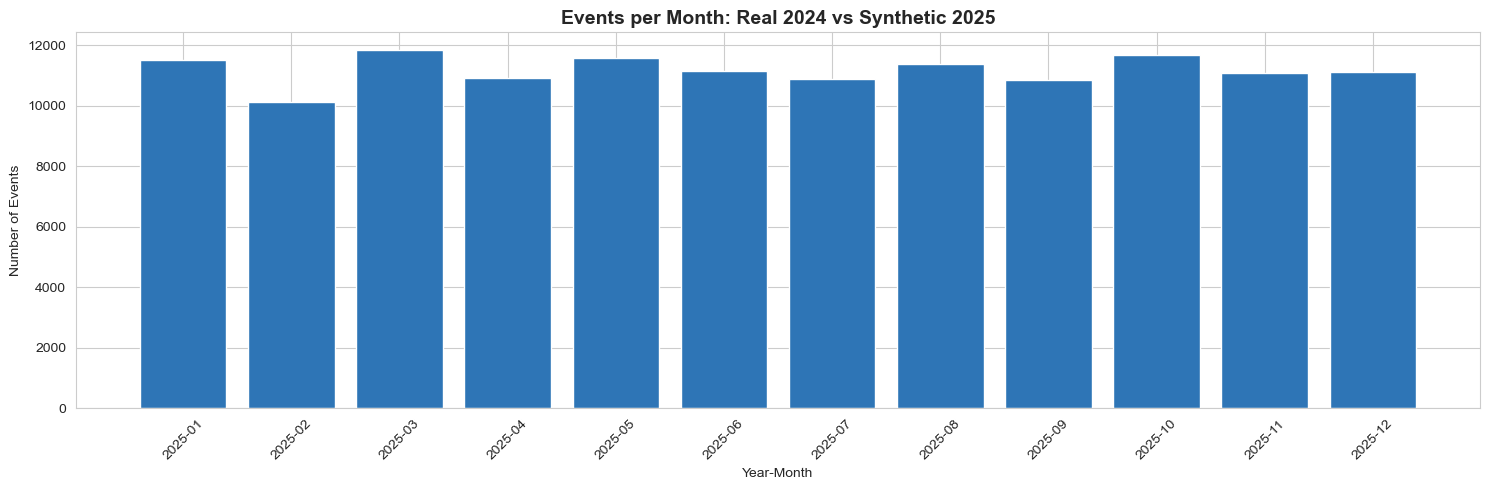

In [11]:
# Events per month across both years
master_df['year_month'] = master_df['timestamp'].dt.to_period('M')
monthly_events = master_df.groupby('year_month').size()

plt.figure(figsize=(15, 5))
colors = ['#1F4E79' if str(x).startswith('2024') else '#2E75B6' 
          for x in monthly_events.index]
plt.bar(monthly_events.index.astype(str), monthly_events.values, color=colors)
plt.title('Events per Month: Real 2024 vs Synthetic 2025', fontsize=14, fontweight='bold')
plt.xlabel('Year-Month')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

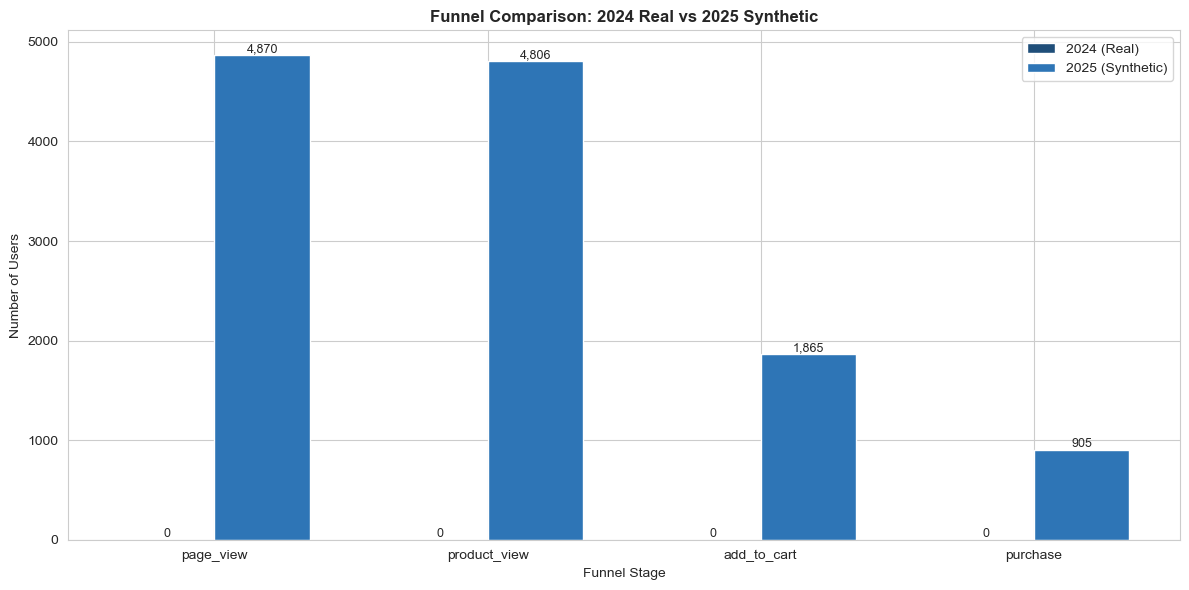


2024 Funnel: {'page_view': 0, 'product_view': 0, 'add_to_cart': 0, 'purchase': 0}
2025 Funnel: {'page_view': 4870, 'product_view': 4806, 'add_to_cart': 1865, 'purchase': 905}


In [12]:
# Compare funnel for 2024 vs 2025
funnel_stages = ['page_view', 'product_view', 'add_to_cart', 'purchase']

def get_funnel(df_subset):
    user_events = df_subset.groupby('user_id')['event_type'].apply(set)
    return {stage: sum(stage in events for events in user_events) for stage in funnel_stages}

df_2024_clean = master_df[master_df['year'] == 2024] if 'year' in master_df.columns else master_df[master_df['timestamp'].dt.year == 2024]
df_2025_clean = master_df[master_df['timestamp'].dt.year == 2025]

funnel_2024 = get_funnel(df_2024_clean)
funnel_2025 = get_funnel(df_2025_clean)

# Side-by-side comparison
x = np.arange(len(funnel_stages))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, list(funnel_2024.values()), width, label='2024 (Real)', color='#1F4E79')
bars2 = ax.bar(x + width/2, list(funnel_2025.values()), width, label='2025 (Synthetic)', color='#2E75B6')

ax.set_xlabel('Funnel Stage')
ax.set_ylabel('Number of Users')
ax.set_title('Funnel Comparison: 2024 Real vs 2025 Synthetic', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(funnel_stages)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n2024 Funnel:", funnel_2024)
print("2025 Funnel:", funnel_2025)

## 5. Save the Processed Master Dataset

In [13]:
# Save the master combined dataset
master_df.to_csv('../data/processed/master_events.csv', index=False)
print(f"✅ Master dataset saved to data/processed/master_events.csv")
print(f"   Total rows: {len(master_df):,}")
print(f"   File size: ~{len(master_df) * 100 / 1_000_000:.1f} MB (estimated)")

✅ Master dataset saved to data/processed/master_events.csv
   Total rows: 134,057
   File size: ~13.4 MB (estimated)


In [14]:
# Save Day 3 processing summary
day3_summary = {
    'day': 3,
    'date': str(pd.Timestamp.now()),
    'raw_2024_rows': len(raw_df),
    'cleaned_2024_rows': len(cleaned_2024),
    'synthetic_2025_rows': len(synthetic_2025),
    'master_total_rows': len(master_df),
    'master_unique_users': int(master_df['user_id'].nunique()),
    'master_unique_sessions': int(master_df['session_id'].nunique()),
    'master_date_range': f"{master_df['timestamp'].min()} to {master_df['timestamp'].max()}",
    'funnel_2024': funnel_2024,
    'funnel_2025': funnel_2025
}

with open('../docs/day3_processing_summary.json', 'w') as f:
    json.dump(day3_summary, f, indent=2, default=str)

print("✅ Day 3 summary saved to docs/day3_processing_summary.json")
print()
print("Day 3 complete! 🎉")

✅ Day 3 summary saved to docs/day3_processing_summary.json

Day 3 complete! 🎉
